In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import importlib
from queue import PriorityQueue

from variable_print import p,ps,pst
from gridworld import GridworldEnv

# #from async_dp import AsyncDP
# import async_dp

from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore")
np.random.seed(0)

## `GridWorld` 초기화하기

가로로 `nx` 개, 세로로 `ny` 개의 칸을 가진 `GridworldEnv`를 만듭니다!

In [4]:
nx = 5
ny = 5
env = GridworldEnv([ny, nx])

## AsyncDP Calss constructor

In [5]:
class AsyncDP:
    @classmethod
    def add_method(cls, fun):
        setattr(cls, fun.__name__, fun)
        return fun

    def __init__(self, gamma=1.0, error_tol=1e-8):
        self.gamma = gamma
        self.error_tol = error_tol

        # Following attributes will be set after call "set_env()"
        self.env = None  # environment
        self.policy = None  # policy
        self.ns = None  # Num. states
        self.na = None  # Num. actions
        self.P = None  # Transition tensor
        self.R = None  # Reward tensor

    def set_env(self, env, policy=None):
        self.env = env
        if policy is None:
            self.policy = np.ones([env.nS, env.nA]) / env.nA

        self.ns = env.nS
        self.na = env.nA
        self.P = env.P_tensor  # Rank 3 tensor, (a,s,s')
        self.R = env.R_tensor  # Rank 2 tensor, (a,s)

        print("Asynchronous DP initialized")
        print("Environment spec:  Num. state = {} | Num. actions = {} ".format(env.nS, env.nA))

    def compute_q_from_v(self, value): # (a,s) <- (a,s)+ gamma * (a,s,s') o ((s,))
        q_pi = self.R.T + self.gamma * self.P.dot(value)
        return q_pi #(a,s)

    def construct_policy_from_v(self, value):
        qs = self.compute_q_from_v(value)  # (a,s)
        # construct greedy policy from Qs.
        pi = np.zeros_like(self.policy)    # (s,a)
        pi[np.arange(qs.shape[1]), qs.argmax(axis=0)] = 1
        return pi #(s,a)

In [6]:
asyncDPagent = AsyncDP()

asyncDPagent.set_env(env)

Asynchronous DP initialized
Environment spec:  Num. state = 25 | Num. actions = 4 


## Full sweeping

__Full sweeping__:앞선 실습에서 처럼 모든 반복에서 $(s)$ 및 $(s,a)$ 에 대해서 update 실행하는 것  


## In-place value iteration(full sweeping)

하나의 Value function 만을 사용  

이 알고리즘이 수렴한다는 사실은 매우 중요   

두 알고리즘의 큰 차이점은<br>
> `Value iteration` 은 $V_k(s)$ 와 $V_k+1(s)$ 을 유지하고, $V_k+1(s)$ 계산할 때 $V_k(s)$을 참조한다. <br>

> `In-place value iteration` 은 $V(s)$만을 유지하고, $V(s')$ 계산할 때 $V(s)$을 참조한다.

입니다.

In [7]:
@AsyncDP.add_method
def in_place_vi(self, v_init=None):
    if v_init is not None:
        value = v_init
    else:
        value = np.zeros(self.ns)

    info = dict()
    info['v'] = list()
    info['pi'] = list()
    info['gap'] = list()
    info['converge'] = False
    info['step'] = None

    steps = 0
    while True:
        # perform in-place VI
        delta_v = 0
        for s in range(self.ns): # 각각의 s에 대해서 v계산: memory 절감
            # qs(a,) <- self.R.T + self.gamma * self.P.dot(value)
            qs = self.compute_q_from_v(value)[:, s] # (a,) <- (a,s)[:,s]
            v = qs.max(axis=0)  # v <- max_a(Q)
            # v 변화량 accum
            delta_v += np.linalg.norm(value[s] - v)
            value[s] = v
        info['v'].append(value.copy())
        # v로 qs구하고, greedy improvement : policy improvement와 동일
        pi = self.construct_policy_from_v(value) #(s,a)
        info['pi'].append(pi)
        info['gap'].append(delta_v)
        print(f"iter[{steps:02d}] Delta V: {delta_v:.5f}")

        if delta_v < self.error_tol:
            if info['converge']:
                info['step'] = steps
                break
            else:
                info['converge'] = True
        else:
            steps += 1
    return info

In [ ]:
%%time
info_ip_vi = asyncDPagent.in_place_vi()

In [ ]:
steps = info_ip_vi['step']

fig, ax = plt.subplots(nrows=steps, ncols=2, figsize=(steps*6* 0.3, 4*3))
for i in range(steps):
    visualize_value_function(ax[i][0],info_ip_vi['v'][i], nx, ny)
    visualize_policy(ax[i][1], info_ip_vi['pi'][i], nx, ny)

## Prioirtized sweeping value iteration

Prioirtized sweeping = 우선순위에 따라(Prioirtized) + V update하기(sweeping)  
> `In-place value iteration` 에서는 임의의 순서(환경의 상태 인덱스 순서)로  update하였음  

임의의 순서를 수정하면 보다 효율적일까?   
__좀 더 좋은 가치 업데이트 순서__ : "Bellman error의 크기에 순서로 update 하자  
> Bellman error : $$e(s) = |\max_{a \in \cal{A}}(R_s^a+ \gamma \sum_{s'\in \cal{S}} P_{ss'}^a V(s')) - V(s)|$$

구현 Idea :  
> 1. `priority_queue = PriorityQueue()` 을 만들고 <br>
> 2. 그 안에 `bellman_errors` 과 `state_indices` 들을 넣어주고
> 3. `priority_queue` 에서 `bellman error` 와 `s` 를 얻어와 v update  

`PriorityQueue():` 값이 낮은 순서부터 리턴하므로, $-e(s)$를 put()해주면 됨     

In [10]:
@AsyncDP.add_method
def prioritized_sweeping_vi(self, v_init=None):

    if v_init is not None:
        value = v_init
    else:
        value = np.zeros(self.ns)

    info = dict()
    info['v'] = list()
    info['pi'] = list()
    info['gap'] = list()
    info['converge'] = False
    info['step'] = None

    steps = 0
    while True:
        # compute the Bellman errors
        # e(s,) <- v(s,) - v(s',)
        bellman_errors = value - (self.R.T + self.P.dot(value)).max(axis=0)
        state_indices = range(self.ns)
        # priority queue <- (-error,s_idx)
        priority_queue = PriorityQueue()
        for bellman_error, s_idx in zip(bellman_errors, state_indices):
            priority_queue.put((-bellman_error, s_idx))
        # pi update
        pi = self.construct_policy_from_v(value)
        info['pi'].append(pi.copy())
        # error가 큰것부터 v update
        delta_v = 0
        while not priority_queue.empty():
            be, s = priority_queue.get()
            qs = self.compute_q_from_v(value)[:, s] # (a,) <- (a,s)[:,s]
            v = qs.max(axis=0)                      # newV(s)= max_aQ(a,)
            delta_v += np.linalg.norm(value[s] - v)
            value[s] = v
        info['gap'].append(delta_v)
        info['v'].append(value.copy())
        print(f"iter[{steps:02d}] Delta V: {delta_v:.5f}")
        if delta_v < self.error_tol:
            if info['converge']:
                info['step'] = steps
                break
            else:
                info['converge'] = True
        else:
            steps += 1
    return info

In [11]:
%%time
info_ps_vi = asyncDPagent.prioritized_sweeping_vi()

iter[00] Delta V: 23.00000
iter[01] Delta V: 19.00000
iter[02] Delta V: 13.00000
iter[03] Delta V: 5.00000
iter[04] Delta V: 0.00000
iter[04] Delta V: 0.00000
CPU times: user 6.4 ms, sys: 0 ns, total: 6.4 ms
Wall time: 6.42 ms


In [ ]:
steps = info_ps_vi['step']

fig, ax = plt.subplots(nrows=steps, ncols=2, figsize=(steps*6* 0.3, 4*3))

for i in range(steps):
    visualize_value_function(ax[i][0],info_ps_vi['v'][i], nx, ny)
    visualize_policy(ax[i][1], info_ps_vi['pi'][i], nx, ny)

## Parital sweeping VI   


### 구현 및 실험 : In-place VI에 추가   
__update_prob__: value iteration동안 state update 적용할 확률   
__vi_iters__: 몇번의 value iteration을 수행할지 선택  

In [13]:
@AsyncDP.add_method
def in_place_vi_partial_update(self,
                                v_init=None,
                                update_prob=0.5,
                                vi_iters: int = 100):

    if v_init is not None:
        value = v_init
    else:
        value = np.zeros(self.ns)

    info = dict()
    info['v'] = list()
    info['pi'] = list()
    info['gap'] = list()

    for steps in range(vi_iters):
        # perform in-place VI
        delta_v = 0
        for s in range(self.ns): # in_place VI(partial sweeping)
            perform_update = np.random.binomial(size=1, n=1, p=update_prob)
            if not perform_update: continue
            # qs(a,) <- self.R.T + self.gamma * self.P.dot(value)
            qs = self.compute_q_from_v(value)[:, s]
            v = qs.max(axis=0)  # v <- max_a(Q)
            # v 변화량 accum
            delta_v += np.linalg.norm(value[s] - v)
            value[s] = v
        info['gap'].append(delta_v)
        info['v'].append(value.copy())
        pi = self.construct_policy_from_v(value)
        info['pi'].append(pi)
        print(f"iter[{steps:02d}] Delta V: {delta_v:.2f}")

    return info

In [ ]:
%%time
info_ip_partial_vi = asyncDPagent.in_place_vi_partial_update(update_prob=0.2,
                                                             vi_iters=60)

In [15]:
steps = len(info_ip_partial_vi['v'])
viz_every = 5
n_figs = steps // viz_every

n_cols = 4
if n_figs % n_cols == 0:
    n_rows = n_figs // n_cols
else:
    n_rows = n_figs // n_cols + 1

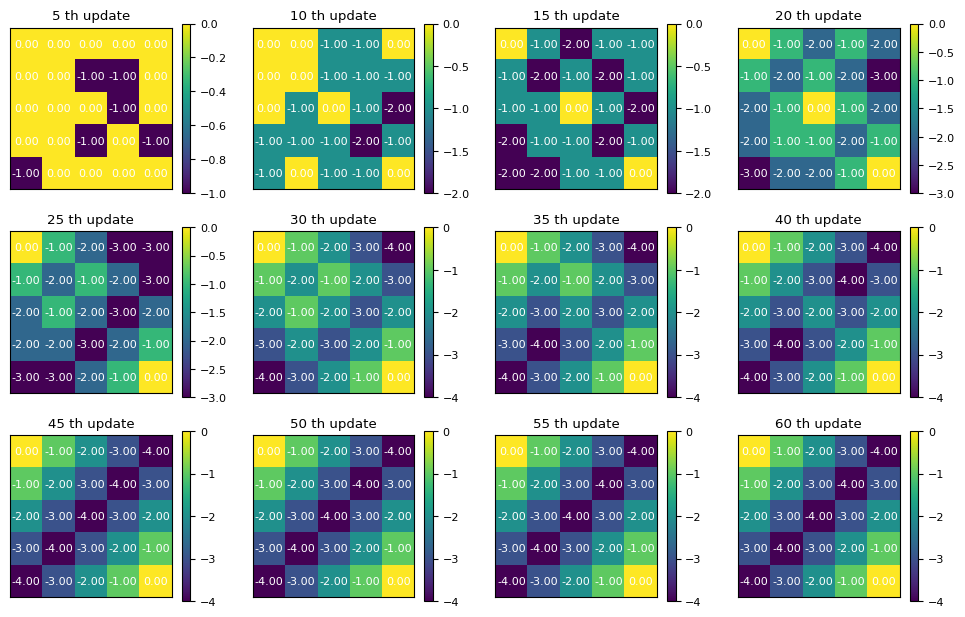

In [18]:
fig, ax = plt.subplots(n_rows,n_cols, figsize=(n_cols*3, n_rows*2.5))
ax = ax.reshape(-1)
for i in range(n_figs):
    viz_i = i * viz_every
    visualize_value_function(ax[i],info_ip_partial_vi['v'][viz_i], nx, ny)
    ax[i].set_title(f"{viz_i+5} th update")

for off_idx in range(n_figs, n_rows*n_cols):
    ax[off_idx].axis('off')

## 실습과제 : in_place_vi_partial_update()를 수정해보자  
### - iteration 횟수를 지정하지 않고 학습을 자동으로 종료하도록 수정하자